Total keypoints in img1: 2674
Total keypoints in img5: 3923
Good matches after ratio test: 87


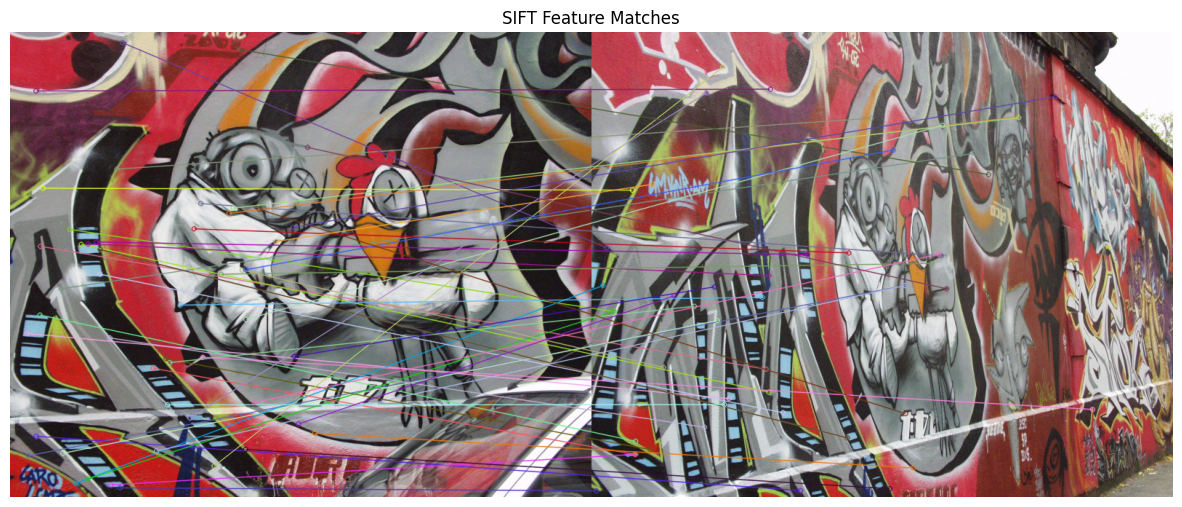

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the images
img1 = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\graf\graf\img1.ppm')
img2 = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\graf\graf\img5.ppm')

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

# Create BFMatcher object
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# Match descriptors using KNN (k=2 for ratio test)
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Apply Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"Total keypoints in img1: {len(keypoints1)}")
print(f"Total keypoints in img5: {len(keypoints2)}")
print(f"Good matches after ratio test: {len(good_matches)}")

# Draw matches
matched_image = cv2.drawMatches(img1, keypoints1, img2, keypoints2, 
                                 good_matches[:50], None, flags=2)
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
plt.title('SIFT Feature Matches')
plt.axis('off')
plt.show()


In [3]:
def compute_homography(pts_src, pts_dst):
    """Compute homography from 4 point correspondences"""
    A = []
    for i in range(4):
        x, y = pts_src[i]
        u, v = pts_dst[i]
        A.append([-x, -y, -1, 0, 0, 0, x*u, y*u, u])
        A.append([0, 0, 0, -x, -y, -1, x*v, y*v, v])
    
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    return H / H[2, 2]

def ransac_homography(keypoints1, keypoints2, matches, 
                      threshold=5.0, max_iterations=1000):
    """RANSAC algorithm for robust homography estimation"""
    # Extract point correspondences
    pts1 = np.float32([keypoints1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([keypoints2[m.trainIdx].pt for m in matches])
    
    best_H = None
    max_inliers = 0
    best_inlier_mask = None
    
    for iteration in range(max_iterations):
        # Randomly select 4 correspondences
        indices = np.random.choice(len(matches), 4, replace=False)
        sample_pts1 = pts1[indices]
        sample_pts2 = pts2[indices]
        
        # Compute homography from 4 points
        H = compute_homography(sample_pts1, sample_pts2)
        
        # Convert points to homogeneous coordinates
        pts1_homogeneous = np.hstack([pts1, np.ones((len(pts1), 1))])
        
        # Project points using homography
        projected = (H @ pts1_homogeneous.T).T
        projected = projected[:, :2] / projected[:, 2:]
        
        # Compute distances
        distances = np.linalg.norm(pts2 - projected, axis=1)
        
        # Count inliers
        inlier_mask = distances < threshold
        num_inliers = np.sum(inlier_mask)
        
        if num_inliers > max_inliers:
            max_inliers = num_inliers
            best_H = H
            best_inlier_mask = inlier_mask
    
    # Refine homography using all inliers
    if best_inlier_mask is not None:
        inlier_pts1 = pts1[best_inlier_mask]
        inlier_pts2 = pts2[best_inlier_mask]
        
        # Use least squares refinement
        A = []
        for i in range(len(inlier_pts1)):
            x, y = inlier_pts1[i]
            u, v = inlier_pts2[i]
            A.append([-x, -y, -1, 0, 0, 0, x*u, y*u, u])
            A.append([0, 0, 0, -x, -y, -1, x*v, y*v, v])
        
        A = np.array(A)
        _, _, Vt = np.linalg.svd(A)
        best_H = Vt[-1].reshape(3, 3)
        best_H = best_H / best_H[2, 2]
    
    return best_H, best_inlier_mask, max_inliers

# Compute homography using RANSAC
H_ransac, inlier_mask, num_inliers = ransac_homography(
    keypoints1, keypoints2, good_matches, threshold=5.0, max_iterations=2000)

print(f"\nRANSAC Homography:\n{H_ransac}")
print(f"Number of inliers: {num_inliers}/{len(good_matches)}")

# Load ground truth homography from dataset
# The dataset typically includes H1to5p file
H_ground_truth = np.loadtxt(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\graf\graf\H1to5p')  # Adjust filename as per dataset
print(f"\nGround Truth Homography:\n{H_ground_truth}")

# Compare homographies
difference = np.abs(H_ransac - H_ground_truth)
print(f"\nHomography Difference (element-wise):\n{difference}")
print(f"Mean absolute error: {np.mean(difference):.6f}")



RANSAC Homography:
[[-1.29507759e+00 -1.95250654e-01  3.15024445e+02]
 [-3.92728967e+00  8.22185384e-01  3.90289586e+02]
 [-1.05136093e-02  1.91118085e-03  1.00000000e+00]]
Number of inliers: 7/87

Ground Truth Homography:
[[ 6.2544644e-01  5.7759174e-02  2.2201217e+02]
 [ 2.2240536e-01  1.1652147e+00 -2.5605611e+01]
 [ 4.9212545e-04 -3.6542424e-05  1.0000000e+00]]

Homography Difference (element-wise):
[[1.92052403e+00 2.53009828e-01 9.30122752e+01]
 [4.14969503e+00 3.43029316e-01 4.15895197e+02]
 [1.10057348e-02 1.94772328e-03 0.00000000e+00]]
Mean absolute error: 57.287409


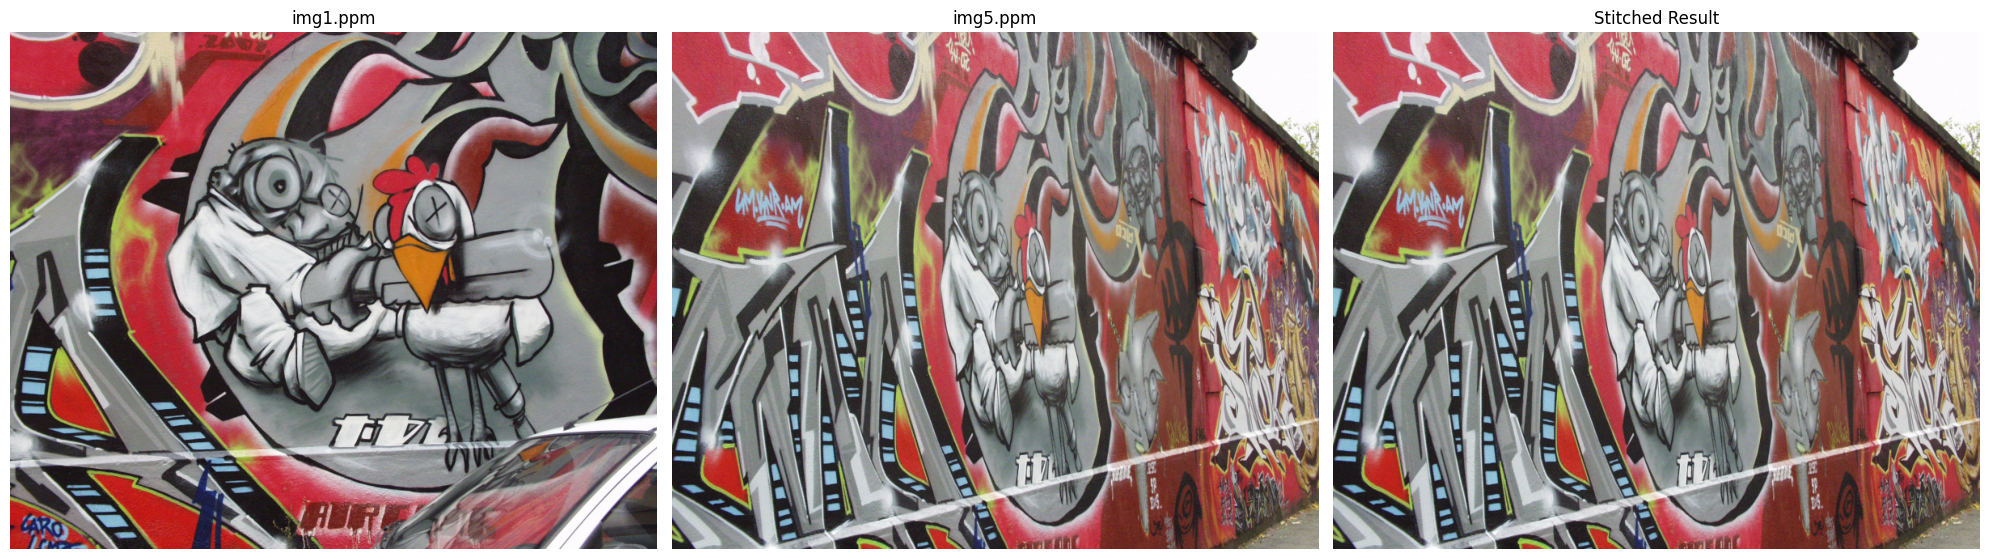

True

In [4]:
def stitch_images(img1, img2, H):
    """Stitch img1 onto img2 using homography H"""
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # Get corners of img1
    corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    
    # Transform corners to img2 coordinate system
    corners_img1_transformed = cv2.perspectiveTransform(corners_img1, H)
    
    # Get corners of img2
    corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)
    
    # Combine all corners
    all_corners = np.concatenate((corners_img1_transformed, corners_img2), axis=0)
    
    # Find bounding box
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)
    
    # Translation to move image to positive coordinates
    translation = np.array([[1, 0, -x_min], 
                            [0, 1, -y_min], 
                            [0, 0, 1]])
    
    # Warp img1 to the output canvas
    output_size = (x_max - x_min, y_max - y_min)
    warped_img1 = cv2.warpPerspective(img1, translation @ H, output_size)
    
    # Place img2 on the canvas
    result = warped_img1.copy()
    result[-y_min:-y_min + h2, -x_min:-x_min + w2] = img2
    
    return result

# Perform stitching
stitched_result = stitch_images(img1, img2, H_ransac)

# Display results
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title('img1.ppm')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title('img5.ppm')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(stitched_result, cv2.COLOR_BGR2RGB))
plt.title('Stitched Result')
plt.axis('off')

plt.tight_layout()
plt.show()

# Save result
cv2.imwrite('stitched_graffiti.jpg', stitched_result)
